In [68]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

tensorflow


In [69]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

/home/jonih/anaconda3/envs/tf_2.21/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [70]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

In [71]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Flatten()(inputs)
x = layers.Dense(1024, activation="relu")(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="cifar10_cnn")

In [72]:
model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

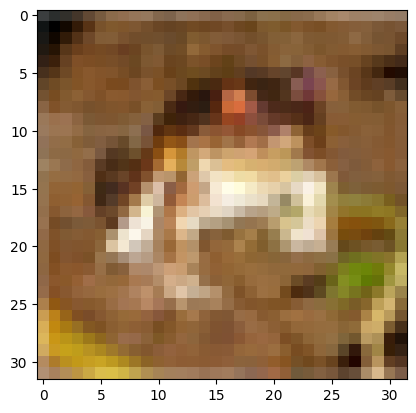

In [73]:
image = x_train[0]
plt.imshow(image)
plt.show()

In [74]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [75]:
history = model.fit(x_train, y_train, batch_size=32, epochs=30, validation_split=0.2)

Epoch 1/25


I0000 00:00:1773957314.848556    6823 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_972295__.14


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3118 - loss: 1.8901 - val_accuracy: 0.3040 - val_loss: 1.9695
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3833 - loss: 1.7122 - val_accuracy: 0.3857 - val_loss: 1.6962
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4195 - loss: 1.6192 - val_accuracy: 0.4203 - val_loss: 1.6262
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4401 - loss: 1.5580 - val_accuracy: 0.4249 - val_loss: 1.5992
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4519 - loss: 1.5244 - val_accuracy: 0.4470 - val_loss: 1.5486
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4683 - loss: 1.4787 - val_accuracy: 0.4488 - val_loss: 1.5558
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4782 - loss: 1.4473 - val_accuracy: 0.4629 - val_loss: 1.5267
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4897 - loss: 1.4189 - val_accurac

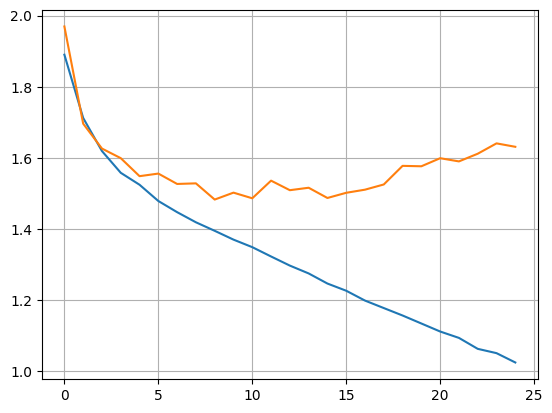

In [76]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

In [77]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 1s - 3ms/step - accuracy: 0.4873 - loss: 1.6231
Test loss: 1.623130440711975
Test accuracy: 0.48730000853538513


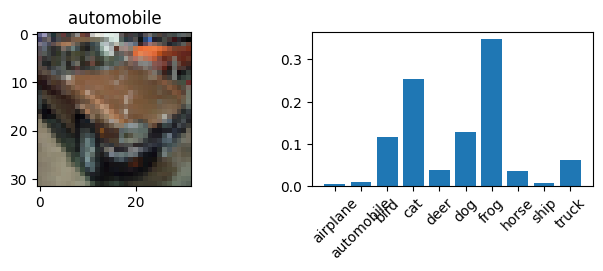

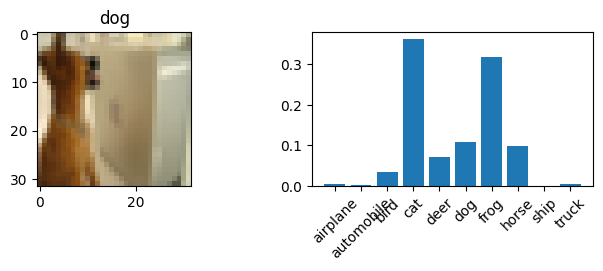

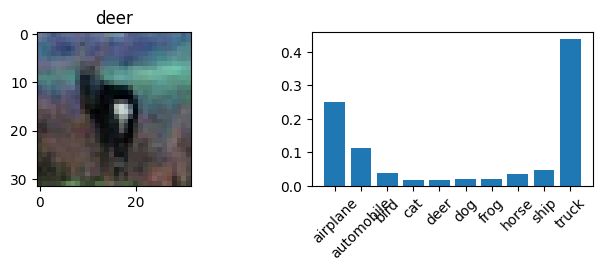

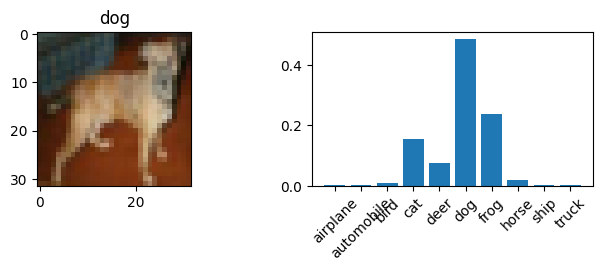

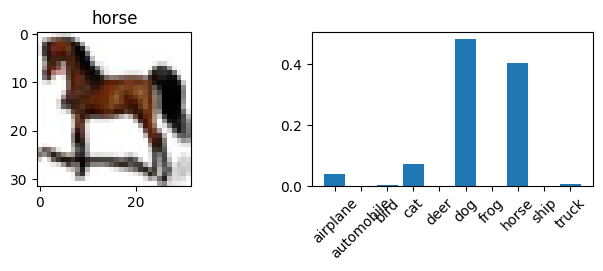

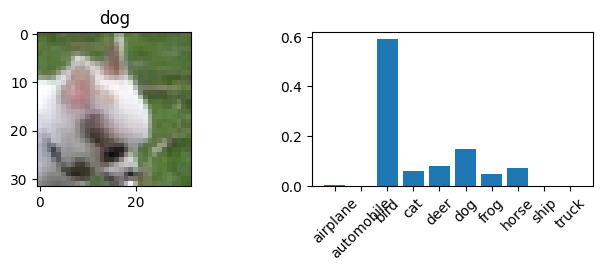

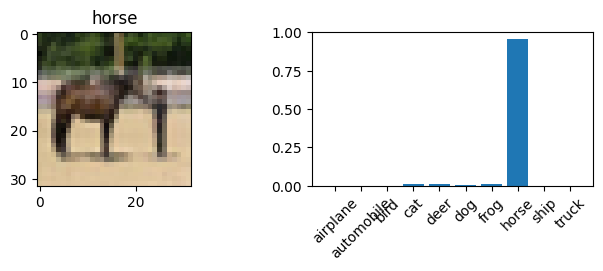

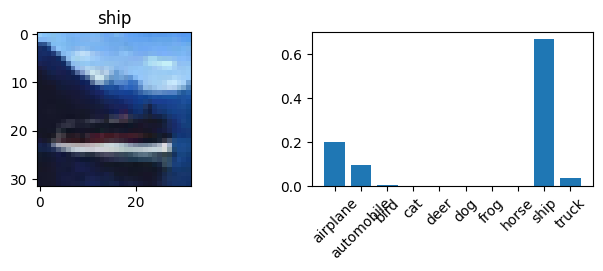

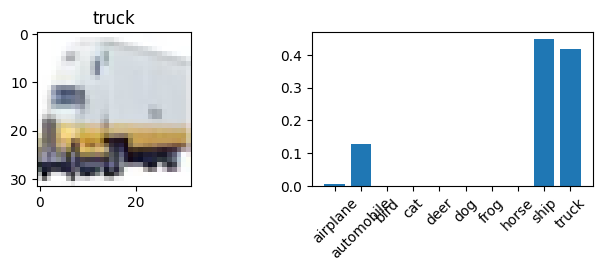

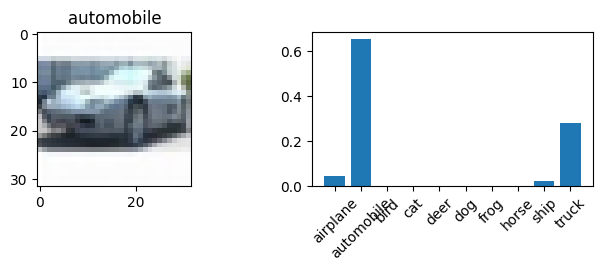

In [78]:
x = x_test
y = model(x)
start = 2000

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

for k in range(10):
    plt.figure(figsize=(8,2))
    plt.subplot(1,2,1)
    plt.imshow(x_test[start+k])
    plt.title(class_names[y_test[start+k][0]])

    plt.subplot(1,2,2)
    plt.bar(range(10), y[start+k].numpy().flatten())
    plt.xticks(range(10), class_names, rotation=45)